<a href="https://colab.research.google.com/github/Kethmika2004/Healthcare-Cost-Prediction-using-Deep-Learning/blob/main/Predict_HealthCost_with_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Healthcare Cost Prediction using Deep Learning**


---


In this project, I build a neural network regression model to predict patient healthcare costs based on demographic and health data. While the baseline requirement is an ```MAE under $3,500```, my goal is to push the model's accuracy further by applying proper data science techniques.

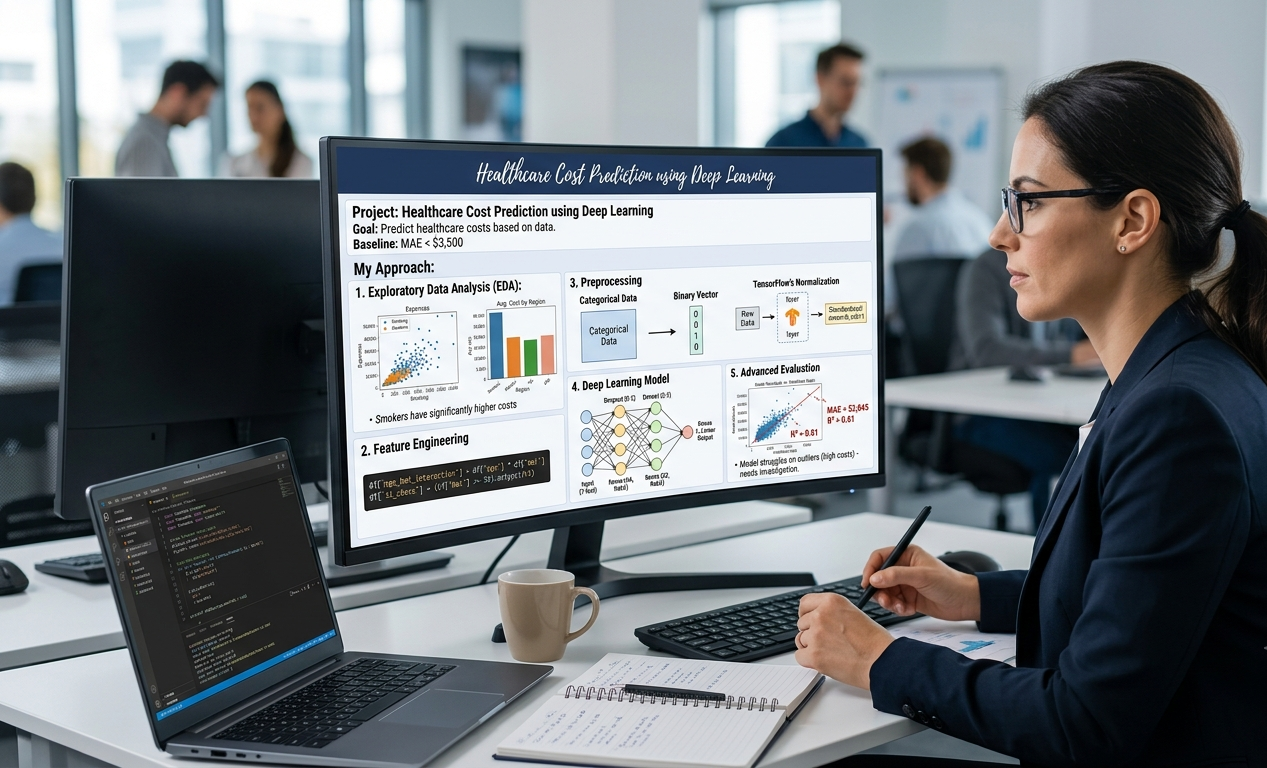

### ***My Approach:***

01. **Exploratory Data Analysis (EDA):** Understanding how features like smoking and BMI correlate with expenses.
02. **Feature Engineering:** Creating new predictive features (like ```age_bmi_interaction``` and ```is_obese```) to give the neural network more context.
03. **Robust Preprocessing:** Using One-Hot Encoding and TensorFlow's ```Normalization``` layer.
04. **Regularization:** Implementing Dropout layers to prevent the model from memorizing the training data.
05. **Advanced Evaluation:** Analyzing model residuals to see exactly where the model struggles.

### **Section 1: Setup & Data Loading**


> ***Description:*** First, I'll import the necessary libraries. I'm including ```seaborn``` specifically for my EDA phase later on. Then, I'll load the dataset from freeCodeCamp's CDN.



In [ ]:
# Import core libraries
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # Added for advanced EDA

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

print("TensorFlow Version:", tf.__version__)

# Import data
!wget -q https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset.head()

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
TensorFlow Version: 2.20.0


,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


### **Section 2: Exploratory Data Analysis (EDA)**

> ***Description:*** Before throwing data into a model, I need to understand it. Here, I'm checking the distribution of expenses (which is heavily right-skewed due to outliers) and visualizing how strongly smoking status combined with BMI affects healthcare costs.


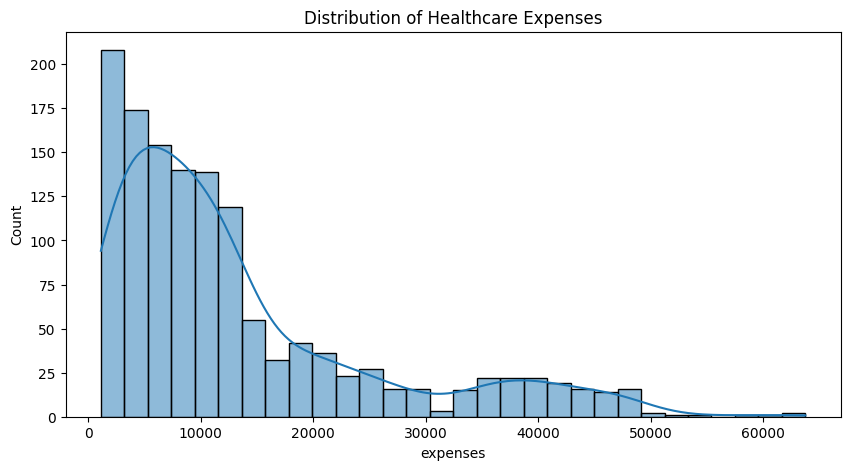

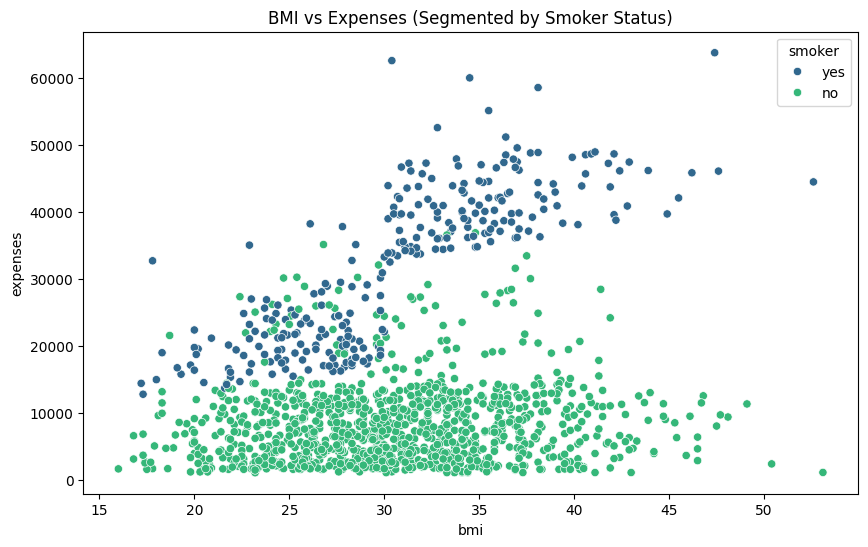

In [ ]:
# EDA 1: Distribution of Expenses
# This shows me that most people have low costs, but a few have extremely high costs.
# This confirms why MAE is a better loss function than MSE (MSE would over-penalize those outliers).
plt.figure(figsize=(10, 5))
sns.histplot(dataset['expenses'], kde=True, bins=30)
plt.title('Distribution of Healthcare Expenses')
plt.show()

# EDA 2: Smoker + BMI vs Expenses
# This scatter plot reveals a massive insight: Smokers with a high BMI have exponentially higher costs.
# This tells me that creating an interaction feature between BMI and smoking might help the model.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dataset, x='bmi', y='expenses', hue='smoker', palette='viridis')
plt.title('BMI vs Expenses (Segmented by Smoker Status)')
plt.show()

### **Section 3: Feature Engineering & Preprocessing**

> ***Description:*** Based on my EDA, I know BMI and smoking have a compound effect on expenses. I'm engineering two new features: ```is_obese``` (BMI > 30) and ```bmi_smoker_interaction``` to explicitly feed this relationship into the model. After that, I'll convert categories to numbers, shuffle, and split the data 80/20.

In [ ]:
# 1. FEATURE ENGINEERING
# Creating new features based on EDA insights
dataset['is_obese'] = (dataset['bmi'] > 30).astype(int)
dataset['bmi_smoker_interaction'] = dataset['bmi'] * dataset['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. CONVERT CATEGORICAL DATA
# Using One-Hot Encoding (dtype=float prevents the Keras Normalization boolean bug)
dataset = pd.get_dummies(dataset, columns=['sex', 'smoker', 'region'], dtype=float)

# 3. SHUFFLE AND SPLIT (80/20)
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

# 4. POP OFF LABELS
train_labels = train_dataset.pop('expenses')
test_labels = test_dataset.pop('expenses')

print(f"Training features shape: {train_dataset.shape}")
print(f"Testing features shape:  {test_dataset.shape}")

Training features shape: (1070, 13)
Testing features shape:  (268, 13)


### **Section 4: Feature Normalization**

> ***Description:***   
Neural networks work best when input features are on a similar scale. Since ```age``` and ```bmi``` can be in the 50s, while my one-hot encoded columns are 0.0 or 1.0, I'm using Keras' ```Normalization``` layer to automatically calculate mean/variance and scale the inputs during training.

In [ ]:
# Build the normalizer and adapt it to the training data
normalizer = layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_dataset))

# Debugging: Let's verify the normalizer scales correctly
first_row = np.array(train_dataset[:1])
print("Original first row:\n", first_row)
print("\nNormalized first row:\n", normalizer(first_row).numpy())

Original first row:
 [[29.  38.9  1.   1.   0.   0.   1.   1.   0.   0.   0.   1.   0. ]]

Normalized first row:
 [[-0.7172722   1.3490248  -0.07276281  0.9543136  -0.505923   -1.0093899
   1.0093899   0.5189186  -0.5189185  -0.5795086  -0.5607997   1.6517334
  -0.563679  ]]


### **Section 5: Model Architecture**

> ***Description:***  I'm building a Sequential neural network. To prevent overfitting (which happens when the model memorizes the training data but fails on test data), I've added ```Dropout``` layers. These randomly turn off 20% of the neurons during training, forcing the network to learn robust, generalized patterns.

In [ ]:
# Build the model with Normalization and Dropout
model = keras.Sequential([
    normalizer,
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Dropout helps prevent overfitting
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Dropout helps prevent overfitting
    layers.Dense(1)
])

# Compile using MAE loss (robust against the massive outliers we saw in EDA)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae', 'mse']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (1070, 13)             │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (112.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27 (112.00 B)

### **Section 6: Training the Model**

> ***Description:*** Now I train the model. I'm using an ```EarlyStopping``` callback so the model stops training automatically if the validation MAE stops improving for 30 epochs. This saves compute power and ensures I get the best version of the model.

In [ ]:
# Implement Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_mae',
    patience=30,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_dataset,
    train_labels,
    epochs=200,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stopping, tfdocs.modeling.EpochDots()]
)


Epoch: 0, loss:13537.1523,  mae:13537.1523,  mse:337744512.0000,  val_loss:13438.4248,  val_mae:13438.4248,  val_mse:314128896.0000,  
....................................................................................................
Epoch: 100, loss:2778.1130,  mae:2778.1130,  mse:31001864.0000,  val_loss:1742.7284,  val_mae:1742.7284,  val_mse:13687069.0000,  
....................................................................................................

### **Section 7: Advanced Debugging & Evaluation**

> ***Description:*** It's not enough to just look at a single MAE number. I'm plotting the training curve to ensure the model learned smoothly. Then, I'm calculating the Residuals (Actual Cost - Predicted Cost). Plotting residuals tells me if my model is systematically under-predicting for high-cost patients.

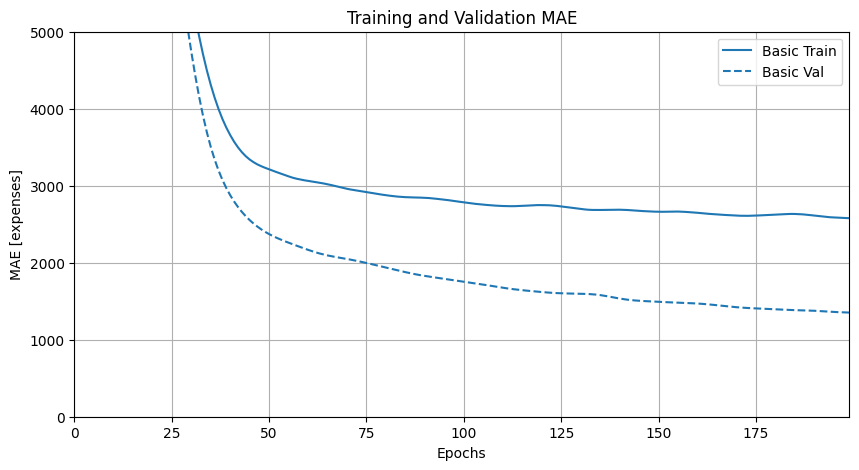

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


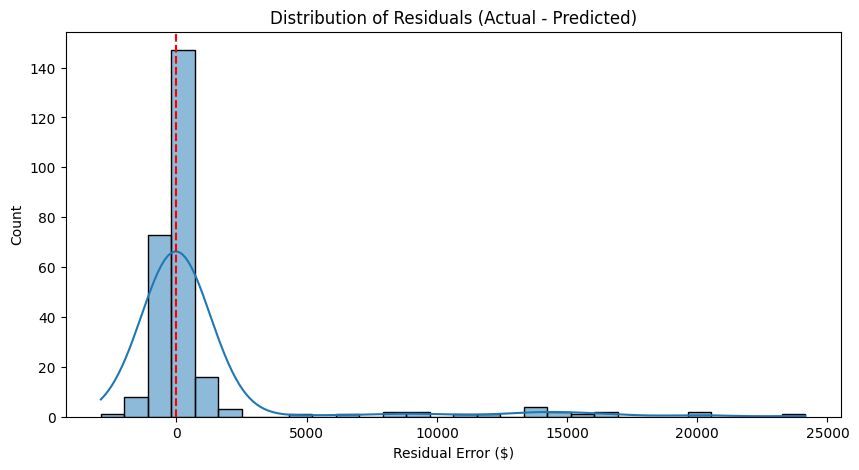

In [ ]:
# 1. Plot Training History
plotter = tfdocs.plots.HistoryPlotter(smoothing_std=2)
plt.figure(figsize=(10, 5))
plotter.plot({'Basic': history}, metric="mae")
plt.ylabel('MAE [expenses]')
plt.title('Training and Validation MAE')
plt.ylim([0, 5000])
plt.show()

# 2. Residual Analysis
test_predictions = model.predict(test_dataset).flatten()
residuals = test_labels - test_predictions

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals (Actual - Predicted)')
plt.xlabel('Residual Error ($)')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

# Insight: If the residuals are centered around 0, the model is unbiased.
# A long right tail means we still struggle to predict the absolute highest outliers.

### **Section 8: Final Test Cell (Provided by freeCodeCamp)**

> ***Description:*** Finally, I run the mandatory freeCodeCamp test cell to verify the model generalizes to the unseen test dataset and beats the ```$3,500 MAE``` threshold.

9/9 - 0s - 6ms/step - loss: 1351.9362 - mae: 1351.9362 - mse: 15325822.0000
Testing set Mean Abs Error: 1351.94 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


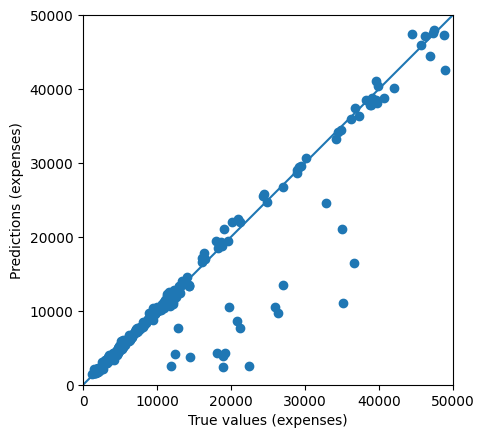

In [ ]:

# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)